# Asian Options: Interactive Analysis & Visualizations

**Product Type:** Path-Dependent Exotic Option  
**Purpose:** Interactive exploration of Asian option pricing, Greeks, and properties

---

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Payoff Diagrams](#2-payoff-diagrams)
3. [Price Surfaces](#3-price-surfaces)
4. [Greeks Analysis](#4-greeks-analysis)
5. [Arithmetic vs Geometric Comparison](#5-arithmetic-vs-geometric-comparison)
6. [Monte Carlo Convergence](#6-monte-carlo-convergence)
7. [Sample Paths Visualization](#7-sample-paths-visualization)

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11

# Color scheme
COLORS = {
    'call_long': '#2ecc71',    # Green
    'call_short': '#e74c3c',   # Red
    'put_long': '#3498db',     # Blue
    'put_short': '#f39c12',    # Orange
    'asian': '#9b59b6',        # Purple
    'vanilla': '#34495e',      # Dark gray
    'arithmetic': '#2ecc71',   # Green
    'geometric': '#e74c3c',    # Red
}

In [2]:
# Base parameters for analysis
BASE_PARAMS = {
    'S0': 100.0,      # Initial spot price
    'K': 100.0,       # Strike price (ATM)
    'T': 1.0,         # Time to maturity (1 year)
    'r': 0.05,        # Domestic risk-free rate (5%)
    'q': 0.02,        # Foreign rate / dividend yield (2%)
    'sigma': 0.20,    # Volatility (20%)
}

print("Base Parameters:")
print("-" * 40)
for key, value in BASE_PARAMS.items():
    print(f"{key:12s}: {value}")

Base Parameters:
----------------------------------------
S0          : 100.0
K           : 100.0
T           : 1.0
r           : 0.05
q           : 0.02
sigma       : 0.2


## Pricing Functions

In [3]:
def black_scholes_call(S, K, T, r, q, sigma):
    """Black-Scholes call option price."""
    if T <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def black_scholes_put(S, K, T, r, q, sigma):
    """Black-Scholes put option price."""
    if T <= 0:
        return max(K - S, 0)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

def geometric_asian_call(S0, K, T, r, q, sigma):
    """
    Closed-form price for geometric average Asian call option.
    
    The geometric average is lognormal, allowing BSM-style pricing.
    """
    if T <= 0:
        return max(S0 - K, 0)
    
    # Adjusted volatility: σ_adj = σ / √3
    sigma_adj = sigma / np.sqrt(3)
    
    # Adjusted rate for continuous geometric average
    # b = (r - q - σ²/6) / 2
    b = 0.5 * (r - q - sigma**2 / 6)
    
    # Use BSM with adjusted parameters
    d1 = (np.log(S0 / K) + (b + 0.5 * sigma_adj**2) * T) / (sigma_adj * np.sqrt(T))
    d2 = d1 - sigma_adj * np.sqrt(T)
    
    return np.exp(-r * T) * (S0 * np.exp(b * T) * norm.cdf(d1) - K * norm.cdf(d2))

def geometric_asian_put(S0, K, T, r, q, sigma):
    """Closed-form price for geometric average Asian put option."""
    if T <= 0:
        return max(K - S0, 0)
    
    sigma_adj = sigma / np.sqrt(3)
    b = 0.5 * (r - q - sigma**2 / 6)
    
    d1 = (np.log(S0 / K) + (b + 0.5 * sigma_adj**2) * T) / (sigma_adj * np.sqrt(T))
    d2 = d1 - sigma_adj * np.sqrt(T)
    
    return np.exp(-r * T) * (K * norm.cdf(-d2) - S0 * np.exp(b * T) * norm.cdf(-d1))

def asian_mc_price(S0, K, T, r, q, sigma, n_paths=100000, n_steps=252, 
                   option_type='call', avg_type='arithmetic', seed=42):
    """
    Monte Carlo pricer for Asian options.
    
    Parameters
    ----------
    avg_type : str
        'arithmetic' or 'geometric'
    
    Returns
    -------
    tuple : (price, std_error, paths, averages)
    """
    np.random.seed(seed)
    
    if T <= 0:
        if option_type == 'call':
            return max(S0 - K, 0), 0.0, None, None
        return max(K - S0, 0), 0.0, None, None
    
    dt = T / n_steps
    drift = (r - q - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt)
    
    # Generate paths using antithetic variates
    Z = np.random.standard_normal((n_paths // 2, n_steps))
    Z = np.vstack([Z, -Z])  # Antithetic
    
    log_returns = drift + diffusion * Z
    log_paths = np.cumsum(log_returns, axis=1)
    
    # Include S0 in paths
    paths = np.column_stack([np.zeros(n_paths), log_paths])
    paths = S0 * np.exp(paths)
    
    # Compute averages
    if avg_type == 'arithmetic':
        averages = np.mean(paths, axis=1)
    else:  # geometric
        averages = np.exp(np.mean(np.log(paths), axis=1))
    
    # Compute payoffs
    if option_type == 'call':
        payoffs = np.maximum(averages - K, 0)
    else:
        payoffs = np.maximum(K - averages, 0)
    
    # Discount
    discounted = np.exp(-r * T) * payoffs
    price = np.mean(discounted)
    std_error = np.std(discounted) / np.sqrt(n_paths)
    
    return price, std_error, paths, averages

## 2. Payoff Diagrams

Visualizing the payoff structure at maturity for Asian options.

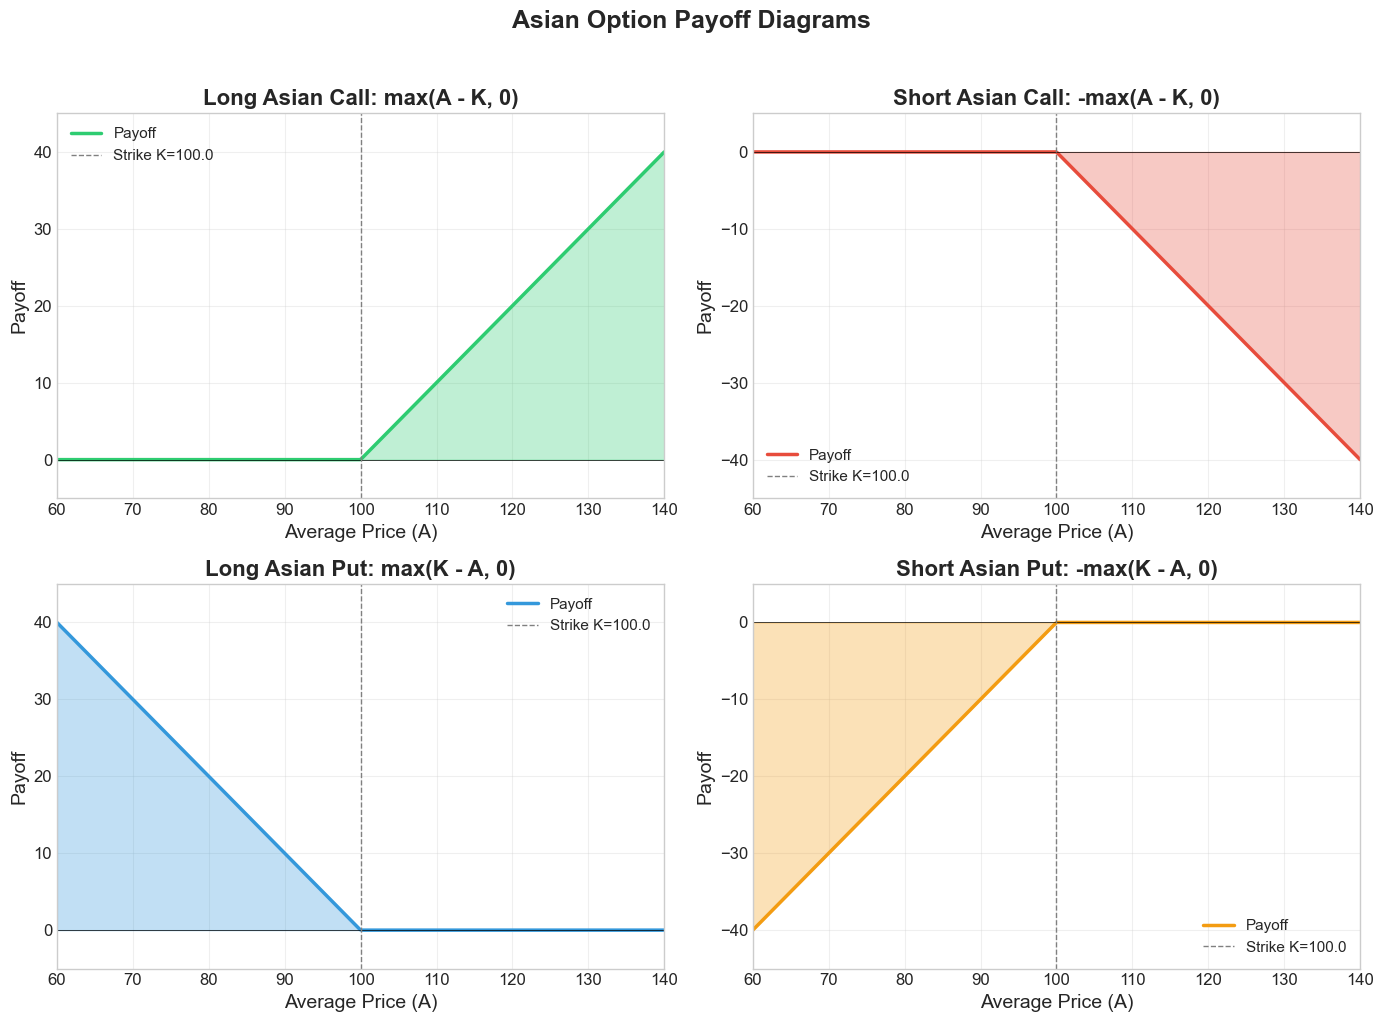

In [4]:
def plot_asian_payoff_diagrams(save_fig: bool = False):
    """
    Plot payoff diagrams for Asian options showing long/short positions.
    """
    K = BASE_PARAMS['K']
    averages = np.linspace(60, 140, 500)
    
    # Payoffs
    call_payoff = np.maximum(averages - K, 0)
    put_payoff = np.maximum(K - averages, 0)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Long Call
    ax = axes[0, 0]
    ax.plot(averages, call_payoff, color=COLORS['call_long'], linewidth=2.5, label='Payoff')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(averages, 0, call_payoff, alpha=0.3, color=COLORS['call_long'])
    ax.set_xlabel('Average Price (A)')
    ax.set_ylabel('Payoff')
    ax.set_title('Long Asian Call: max(A - K, 0)', fontweight='bold')
    ax.legend()
    ax.set_xlim(60, 140)
    ax.set_ylim(-5, 45)
    ax.grid(True, alpha=0.3)
    
    # Short Call
    ax = axes[0, 1]
    ax.plot(averages, -call_payoff, color=COLORS['call_short'], linewidth=2.5, label='Payoff')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(averages, 0, -call_payoff, alpha=0.3, color=COLORS['call_short'])
    ax.set_xlabel('Average Price (A)')
    ax.set_ylabel('Payoff')
    ax.set_title('Short Asian Call: -max(A - K, 0)', fontweight='bold')
    ax.legend()
    ax.set_xlim(60, 140)
    ax.set_ylim(-45, 5)
    ax.grid(True, alpha=0.3)
    
    # Long Put
    ax = axes[1, 0]
    ax.plot(averages, put_payoff, color=COLORS['put_long'], linewidth=2.5, label='Payoff')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(averages, 0, put_payoff, alpha=0.3, color=COLORS['put_long'])
    ax.set_xlabel('Average Price (A)')
    ax.set_ylabel('Payoff')
    ax.set_title('Long Asian Put: max(K - A, 0)', fontweight='bold')
    ax.legend()
    ax.set_xlim(60, 140)
    ax.set_ylim(-5, 45)
    ax.grid(True, alpha=0.3)
    
    # Short Put
    ax = axes[1, 1]
    ax.plot(averages, -put_payoff, color=COLORS['put_short'], linewidth=2.5, label='Payoff')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=K, color='gray', linestyle='--', linewidth=1, label=f'Strike K={K}')
    ax.fill_between(averages, 0, -put_payoff, alpha=0.3, color=COLORS['put_short'])
    ax.set_xlabel('Average Price (A)')
    ax.set_ylabel('Payoff')
    ax.set_title('Short Asian Put: -max(K - A, 0)', fontweight='bold')
    ax.legend()
    ax.set_xlim(60, 140)
    ax.set_ylim(-45, 5)
    ax.grid(True, alpha=0.3)
    
    plt.suptitle('Asian Option Payoff Diagrams', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_fig:
        plt.savefig('asian_payoff_diagrams.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_asian_payoff_diagrams(save_fig=False)

## 3. Price Surfaces

3D visualization of option price as a function of spot and time/volatility.

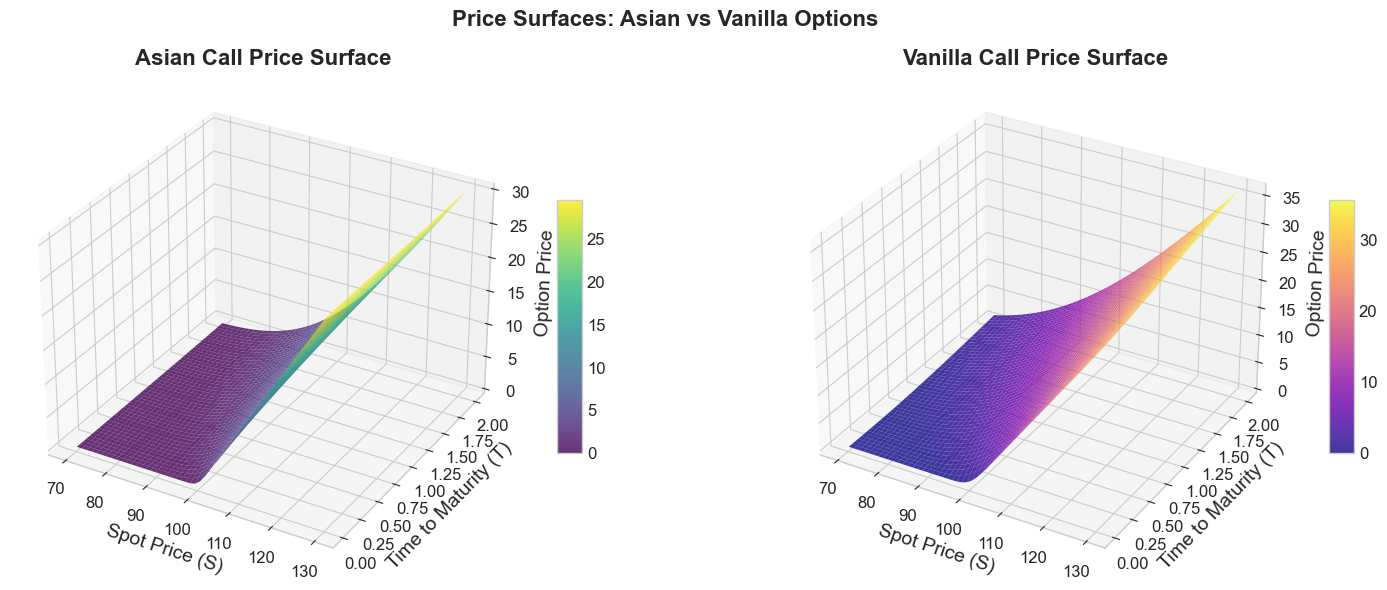

In [5]:
def plot_price_surface_spot_time(save_fig: bool = False):
    """
    Plot 3D price surface: Price vs Spot vs Time to Maturity.
    """
    K = BASE_PARAMS['K']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    spots = np.linspace(70, 130, 50)
    times = np.linspace(0.01, 2.0, 50)
    S_grid, T_grid = np.meshgrid(spots, times)
    
    # Compute prices (using geometric Asian as approximation for speed)
    prices_asian = np.zeros_like(S_grid)
    prices_vanilla = np.zeros_like(S_grid)
    
    for i in range(len(times)):
        for j in range(len(spots)):
            prices_asian[i, j] = geometric_asian_call(spots[j], K, times[i], r, q, sigma)
            prices_vanilla[i, j] = black_scholes_call(spots[j], K, times[i], r, q, sigma)
    
    fig = plt.figure(figsize=(16, 6))
    
    # Asian Call Surface
    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(S_grid, T_grid, prices_asian, cmap=cm.viridis, alpha=0.8)
    ax1.set_xlabel('Spot Price (S)')
    ax1.set_ylabel('Time to Maturity (T)')
    ax1.set_zlabel('Option Price')
    ax1.set_title('Asian Call Price Surface', fontweight='bold')
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
    
    # Vanilla Call Surface
    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(S_grid, T_grid, prices_vanilla, cmap=cm.plasma, alpha=0.8)
    ax2.set_xlabel('Spot Price (S)')
    ax2.set_ylabel('Time to Maturity (T)')
    ax2.set_zlabel('Option Price')
    ax2.set_title('Vanilla Call Price Surface', fontweight='bold')
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)
    
    plt.suptitle('Price Surfaces: Asian vs Vanilla Options', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('asian_price_surface.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_price_surface_spot_time(save_fig=False)

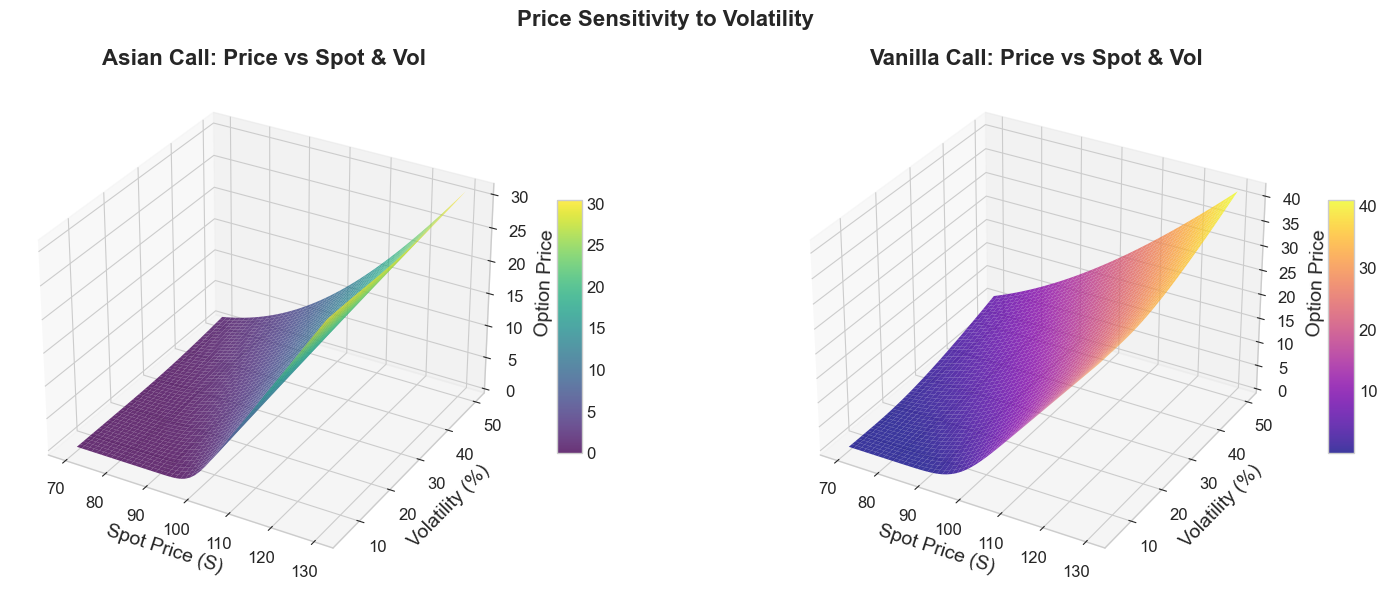

In [6]:
def plot_price_surface_spot_vol(save_fig: bool = False):
    """
    Plot 3D price surface: Price vs Spot vs Volatility.
    """
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    
    spots = np.linspace(70, 130, 50)
    vols = np.linspace(0.05, 0.50, 50)
    S_grid, V_grid = np.meshgrid(spots, vols)
    
    prices_asian = np.zeros_like(S_grid)
    prices_vanilla = np.zeros_like(S_grid)
    
    for i in range(len(vols)):
        for j in range(len(spots)):
            prices_asian[i, j] = geometric_asian_call(spots[j], K, T, r, q, vols[i])
            prices_vanilla[i, j] = black_scholes_call(spots[j], K, T, r, q, vols[i])
    
    fig = plt.figure(figsize=(16, 6))
    
    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(S_grid, V_grid * 100, prices_asian, cmap=cm.viridis, alpha=0.8)
    ax1.set_xlabel('Spot Price (S)')
    ax1.set_ylabel('Volatility (%)')
    ax1.set_zlabel('Option Price')
    ax1.set_title('Asian Call: Price vs Spot & Vol', fontweight='bold')
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
    
    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(S_grid, V_grid * 100, prices_vanilla, cmap=cm.plasma, alpha=0.8)
    ax2.set_xlabel('Spot Price (S)')
    ax2.set_ylabel('Volatility (%)')
    ax2.set_zlabel('Option Price')
    ax2.set_title('Vanilla Call: Price vs Spot & Vol', fontweight='bold')
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)
    
    plt.suptitle('Price Sensitivity to Volatility', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('asian_price_vol_surface.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_price_surface_spot_vol(save_fig=False)

## 4. Greeks Analysis

Visualization of Delta, Gamma, Vega, Theta, and Rho for Asian options.

In [7]:
def compute_greeks_fd(price_func, S0, K, T, r, q, sigma, epsilon=0.01):
    """
    Compute Greeks using finite differences.
    
    Returns: dict with delta, gamma, vega, theta, rho
    """
    base_price = price_func(S0, K, T, r, q, sigma)
    
    # Delta: dV/dS
    dS = S0 * epsilon
    V_up = price_func(S0 + dS, K, T, r, q, sigma)
    V_down = price_func(S0 - dS, K, T, r, q, sigma)
    delta = (V_up - V_down) / (2 * dS)
    
    # Gamma: d²V/dS²
    gamma = (V_up - 2 * base_price + V_down) / (dS ** 2)
    
    # Vega: dV/dσ (per 1% vol change)
    d_sigma = 0.01
    V_vol_up = price_func(S0, K, T, r, q, sigma + d_sigma)
    V_vol_down = price_func(S0, K, T, r, q, sigma - d_sigma)
    vega = (V_vol_up - V_vol_down) / 2  # Per 1% change
    
    # Theta: dV/dt (per day)
    dt = 1 / 365
    if T > dt:
        V_t_down = price_func(S0, K, T - dt, r, q, sigma)
        theta = (V_t_down - base_price)  # Negative means time decay
    else:
        theta = 0.0
    
    # Rho: dV/dr (per 1% rate change)
    dr = 0.01
    V_r_up = price_func(S0, K, T, r + dr, q, sigma)
    rho = V_r_up - base_price
    
    return {
        'delta': delta,
        'gamma': gamma,
        'vega': vega,
        'theta': theta,
        'rho': rho
    }

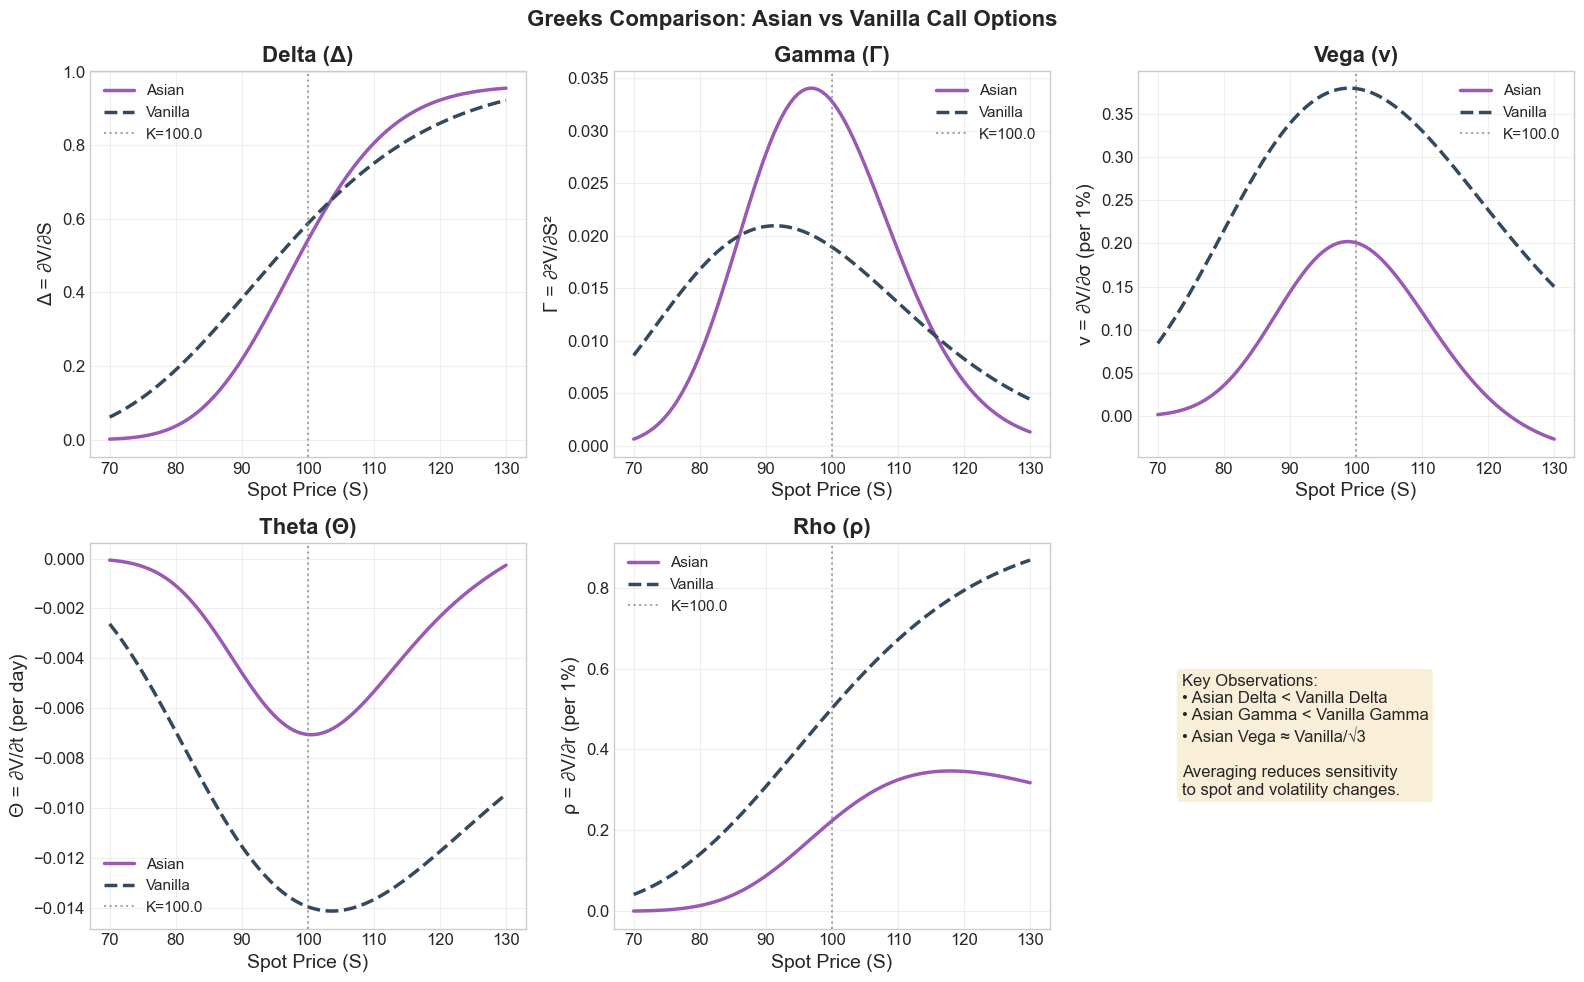

In [8]:
def plot_greeks_vs_spot(save_fig: bool = False):
    """
    Plot all Greeks as a function of spot price for Asian vs Vanilla.
    """
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    spots = np.linspace(70, 130, 100)
    
    # Compute Greeks
    asian_greeks = {'delta': [], 'gamma': [], 'vega': [], 'theta': [], 'rho': []}
    vanilla_greeks = {'delta': [], 'gamma': [], 'vega': [], 'theta': [], 'rho': []}
    
    for S in spots:
        ag = compute_greeks_fd(geometric_asian_call, S, K, T, r, q, sigma)
        vg = compute_greeks_fd(black_scholes_call, S, K, T, r, q, sigma)
        for greek in asian_greeks:
            asian_greeks[greek].append(ag[greek])
            vanilla_greeks[greek].append(vg[greek])
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    greek_names = ['delta', 'gamma', 'vega', 'theta', 'rho']
    titles = ['Delta (Δ)', 'Gamma (Γ)', 'Vega (ν)', 'Theta (Θ)', 'Rho (ρ)']
    ylabels = ['Δ = ∂V/∂S', 'Γ = ∂²V/∂S²', 'ν = ∂V/∂σ (per 1%)', 'Θ = ∂V/∂t (per day)', 'ρ = ∂V/∂r (per 1%)']
    
    for idx, (greek, title, ylabel) in enumerate(zip(greek_names, titles, ylabels)):
        row, col = idx // 3, idx % 3
        ax = axes[row, col]
        
        ax.plot(spots, asian_greeks[greek], color=COLORS['asian'], linewidth=2.5, label='Asian')
        ax.plot(spots, vanilla_greeks[greek], color=COLORS['vanilla'], linewidth=2.5, 
                linestyle='--', label='Vanilla')
        ax.axvline(x=K, color='gray', linestyle=':', alpha=0.7, label=f'K={K}')
        ax.set_xlabel('Spot Price (S)')
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Remove empty subplot
    axes[1, 2].axis('off')
    
    # Add text summary
    textstr = '\n'.join([
        'Key Observations:',
        '• Asian Delta < Vanilla Delta',
        '• Asian Gamma < Vanilla Gamma',
        '• Asian Vega ≈ Vanilla/√3',
        '',
        'Averaging reduces sensitivity',
        'to spot and volatility changes.'
    ])
    axes[1, 2].text(0.1, 0.5, textstr, transform=axes[1, 2].transAxes, fontsize=12,
                    verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Greeks Comparison: Asian vs Vanilla Call Options', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('asian_greeks_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_greeks_vs_spot(save_fig=False)

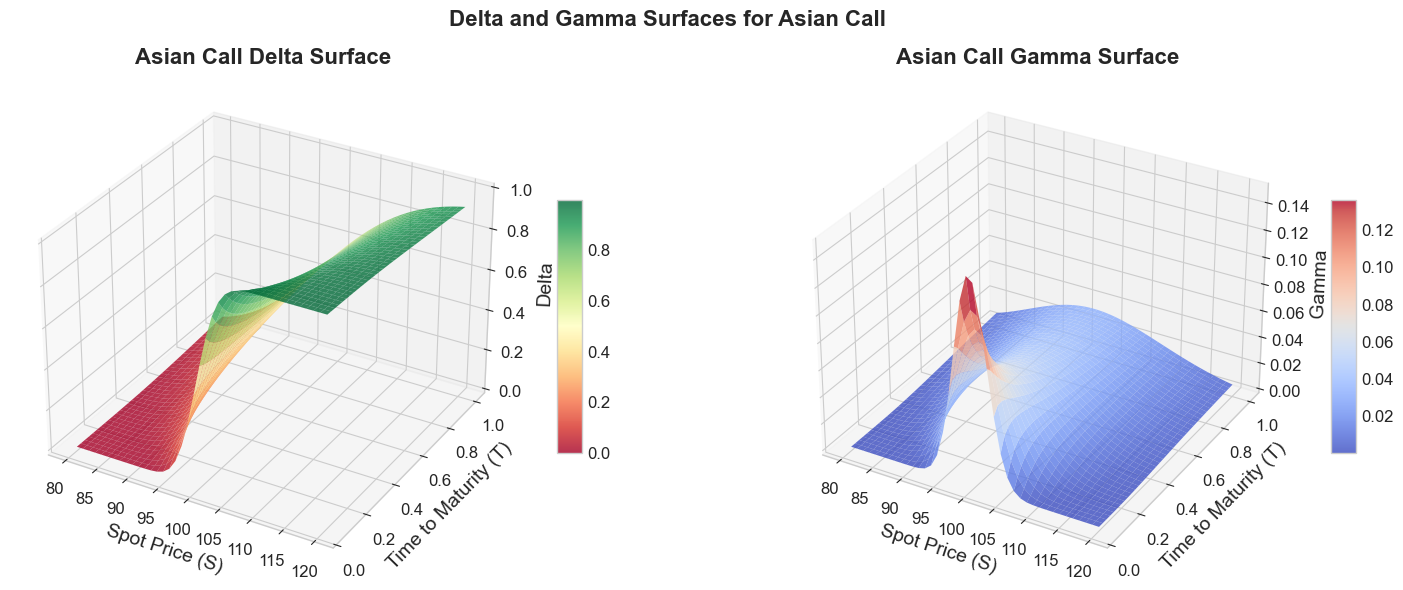

In [9]:
def plot_delta_gamma_surface(save_fig: bool = False):
    """
    3D surface plots of Delta and Gamma vs Spot and Time.
    """
    K = BASE_PARAMS['K']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    spots = np.linspace(80, 120, 40)
    times = np.linspace(0.05, 1.0, 40)
    S_grid, T_grid = np.meshgrid(spots, times)
    
    delta_asian = np.zeros_like(S_grid)
    gamma_asian = np.zeros_like(S_grid)
    
    for i in range(len(times)):
        for j in range(len(spots)):
            greeks = compute_greeks_fd(geometric_asian_call, spots[j], K, times[i], r, q, sigma)
            delta_asian[i, j] = greeks['delta']
            gamma_asian[i, j] = greeks['gamma']
    
    fig = plt.figure(figsize=(16, 6))
    
    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(S_grid, T_grid, delta_asian, cmap=cm.RdYlGn, alpha=0.8)
    ax1.set_xlabel('Spot Price (S)')
    ax1.set_ylabel('Time to Maturity (T)')
    ax1.set_zlabel('Delta')
    ax1.set_title('Asian Call Delta Surface', fontweight='bold')
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
    
    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(S_grid, T_grid, gamma_asian, cmap=cm.coolwarm, alpha=0.8)
    ax2.set_xlabel('Spot Price (S)')
    ax2.set_ylabel('Time to Maturity (T)')
    ax2.set_zlabel('Gamma')
    ax2.set_title('Asian Call Gamma Surface', fontweight='bold')
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)
    
    plt.suptitle('Delta and Gamma Surfaces for Asian Call', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('asian_delta_gamma_surface.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_delta_gamma_surface(save_fig=False)

## 5. Arithmetic vs Geometric Comparison

Demonstrating Jensen's inequality and price differences.

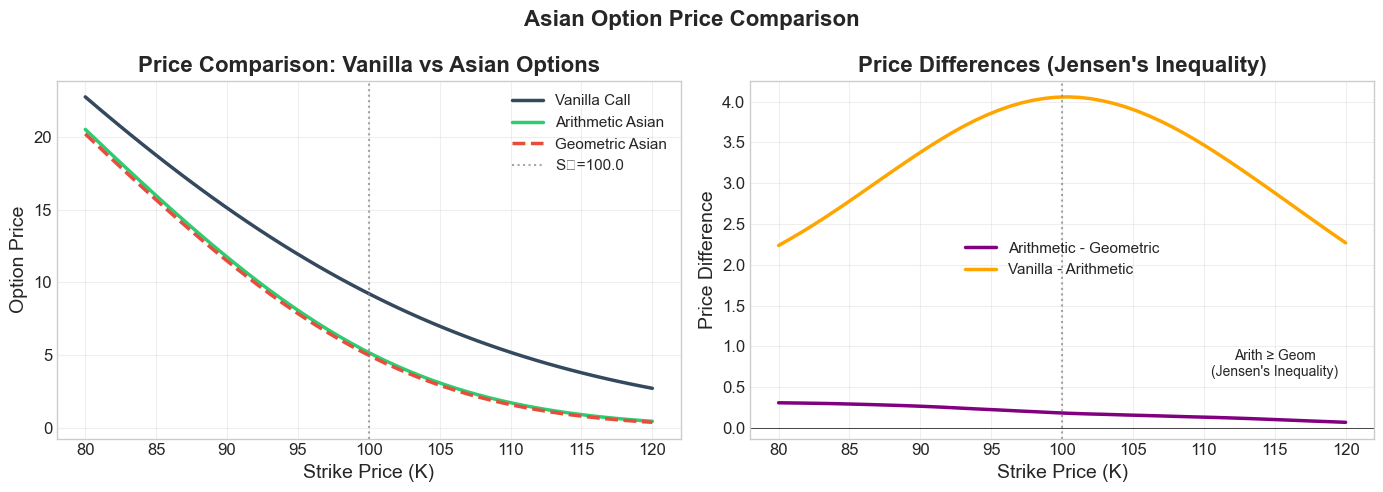

In [10]:
def plot_arith_vs_geom_comparison(save_fig: bool = False):
    """
    Compare arithmetic vs geometric Asian option prices.
    """
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    S0 = BASE_PARAMS['S0']
    
    # Compare across strikes
    strikes = np.linspace(80, 120, 50)
    
    arith_prices = []
    geom_prices = []
    vanilla_prices = []
    
    for K_i in strikes:
        arith_price, _, _, _ = asian_mc_price(S0, K_i, T, r, q, sigma, n_paths=50000, avg_type='arithmetic')
        geom_price = geometric_asian_call(S0, K_i, T, r, q, sigma)
        vanilla_price = black_scholes_call(S0, K_i, T, r, q, sigma)
        
        arith_prices.append(arith_price)
        geom_prices.append(geom_price)
        vanilla_prices.append(vanilla_price)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Price comparison
    ax = axes[0]
    ax.plot(strikes, vanilla_prices, color=COLORS['vanilla'], linewidth=2.5, label='Vanilla Call')
    ax.plot(strikes, arith_prices, color=COLORS['arithmetic'], linewidth=2.5, label='Arithmetic Asian')
    ax.plot(strikes, geom_prices, color=COLORS['geometric'], linewidth=2.5, linestyle='--', label='Geometric Asian')
    ax.axvline(x=S0, color='gray', linestyle=':', alpha=0.7, label=f'S₀={S0}')
    ax.set_xlabel('Strike Price (K)')
    ax.set_ylabel('Option Price')
    ax.set_title('Price Comparison: Vanilla vs Asian Options', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Price difference
    ax = axes[1]
    diff_arith_geom = np.array(arith_prices) - np.array(geom_prices)
    diff_vanilla_arith = np.array(vanilla_prices) - np.array(arith_prices)
    
    ax.plot(strikes, diff_arith_geom, color='purple', linewidth=2.5, label='Arithmetic - Geometric')
    ax.plot(strikes, diff_vanilla_arith, color='orange', linewidth=2.5, label='Vanilla - Arithmetic')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=S0, color='gray', linestyle=':', alpha=0.7)
    ax.set_xlabel('Strike Price (K)')
    ax.set_ylabel('Price Difference')
    ax.set_title('Price Differences (Jensen\'s Inequality)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add annotation
    ax.annotate('Arith ≥ Geom\n(Jensen\'s Inequality)', 
                xy=(110, diff_arith_geom[35]), xytext=(115, diff_arith_geom[35] + 0.5),
                fontsize=10, ha='center')
    
    plt.suptitle('Asian Option Price Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('asian_arith_vs_geom.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_arith_vs_geom_comparison(save_fig=False)

## 6. Monte Carlo Convergence

Demonstrating the O(1/√n) convergence rate of Monte Carlo.

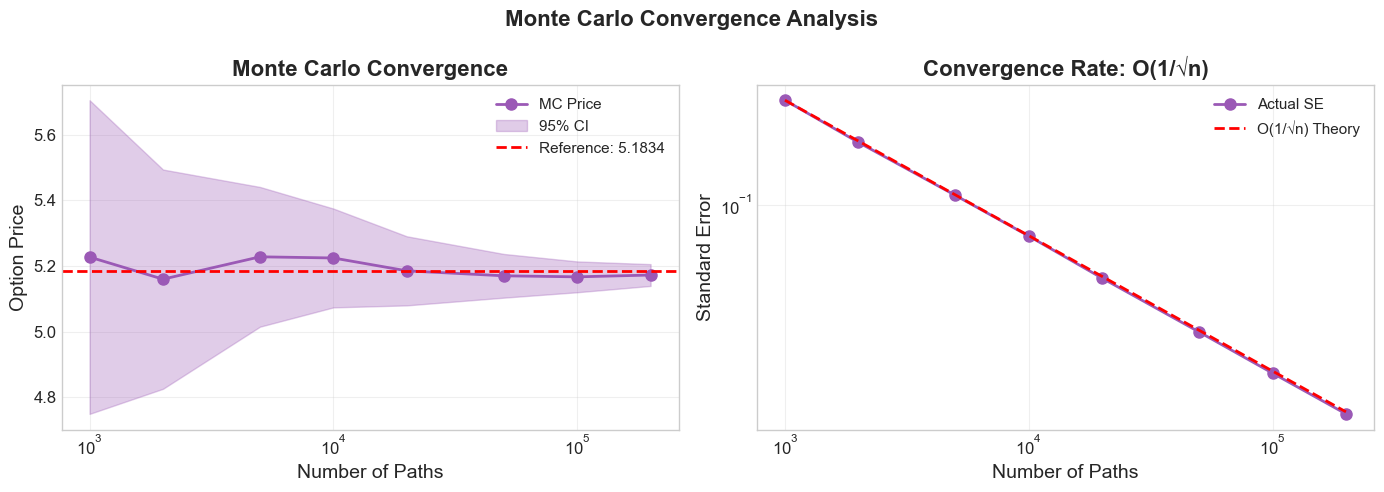

In [11]:
def plot_mc_convergence(save_fig: bool = False):
    """
    Plot Monte Carlo convergence for Asian option pricing.
    """
    S0 = BASE_PARAMS['S0']
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    # Run with increasing number of paths
    path_counts = [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000]
    
    prices = []
    std_errors = []
    
    for n_paths in path_counts:
        price, se, _, _ = asian_mc_price(S0, K, T, r, q, sigma, n_paths=n_paths, seed=42)
        prices.append(price)
        std_errors.append(se)
    
    # Reference price (high accuracy)
    ref_price, _, _, _ = asian_mc_price(S0, K, T, r, q, sigma, n_paths=500000, seed=42)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Price convergence
    ax = axes[0]
    ax.plot(path_counts, prices, 'o-', color=COLORS['asian'], linewidth=2, markersize=8, label='MC Price')
    ax.fill_between(path_counts, 
                    np.array(prices) - 1.96 * np.array(std_errors),
                    np.array(prices) + 1.96 * np.array(std_errors),
                    alpha=0.3, color=COLORS['asian'], label='95% CI')
    ax.axhline(y=ref_price, color='red', linestyle='--', linewidth=2, label=f'Reference: {ref_price:.4f}')
    ax.set_xscale('log')
    ax.set_xlabel('Number of Paths')
    ax.set_ylabel('Option Price')
    ax.set_title('Monte Carlo Convergence', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Standard error vs 1/sqrt(n)
    ax = axes[1]
    theoretical_se = std_errors[0] * np.sqrt(path_counts[0]) / np.sqrt(np.array(path_counts))
    
    ax.plot(path_counts, std_errors, 'o-', color=COLORS['asian'], linewidth=2, markersize=8, label='Actual SE')
    ax.plot(path_counts, theoretical_se, '--', color='red', linewidth=2, label='O(1/√n) Theory')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Number of Paths')
    ax.set_ylabel('Standard Error')
    ax.set_title('Convergence Rate: O(1/√n)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.suptitle('Monte Carlo Convergence Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('asian_mc_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_mc_convergence(save_fig=False)

## 7. Sample Paths Visualization

Visualizing simulated paths and their averages.

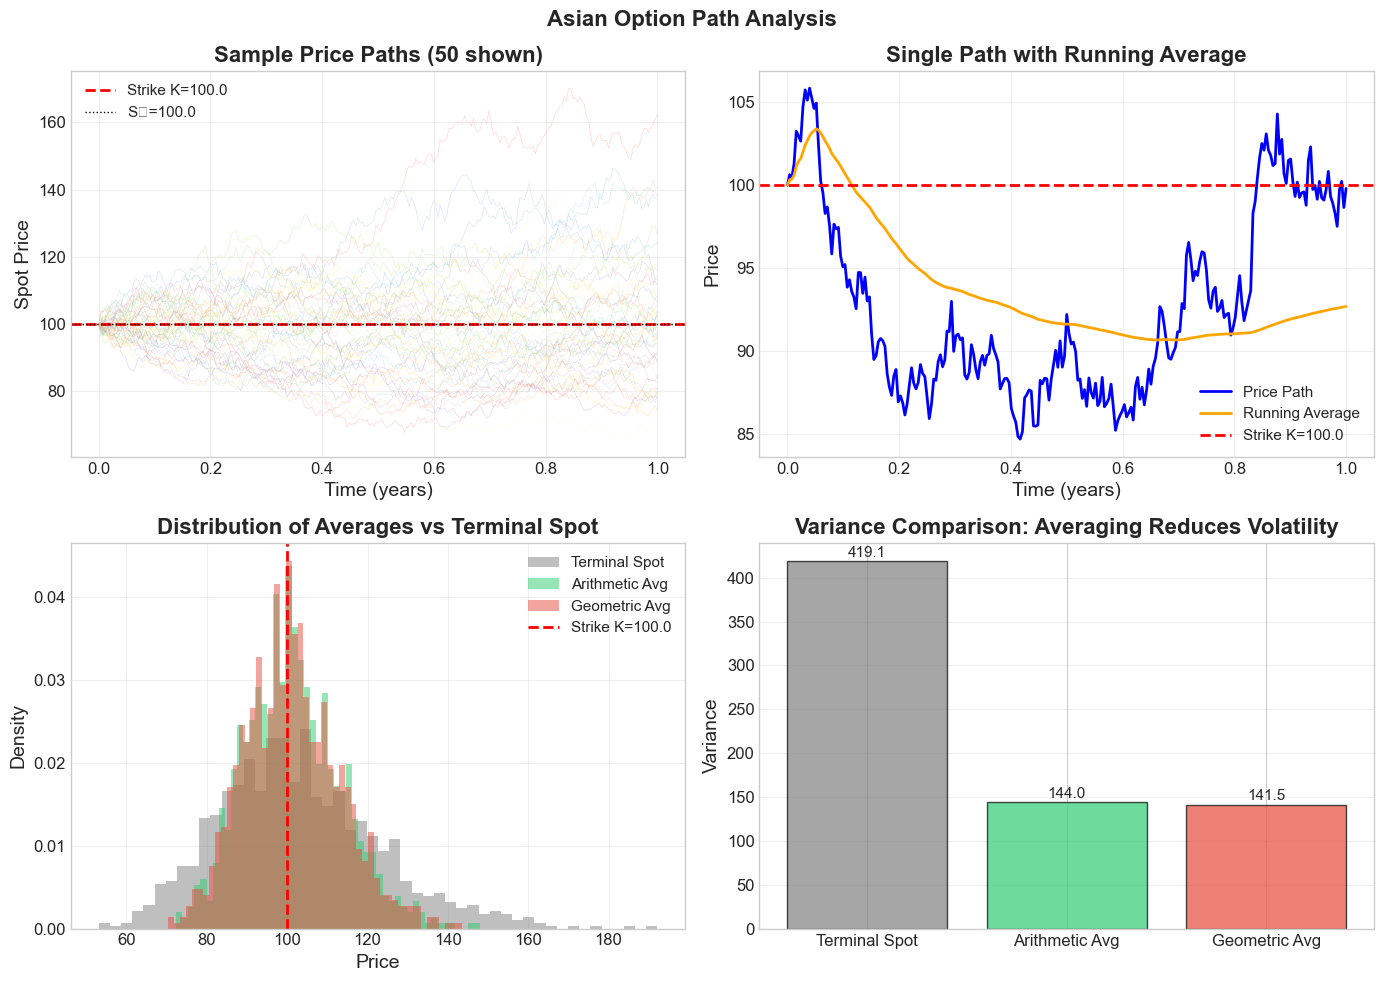

In [12]:
def plot_sample_paths(save_fig: bool = False):
    """
    Visualize sample paths and their arithmetic/geometric averages.
    """
    S0 = BASE_PARAMS['S0']
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    # Generate paths
    _, _, paths, avgs = asian_mc_price(S0, K, T, r, q, sigma, n_paths=1000, n_steps=252, seed=42)
    
    times = np.linspace(0, T, paths.shape[1])
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Sample paths
    ax = axes[0, 0]
    for i in range(min(50, paths.shape[0])):
        ax.plot(times, paths[i, :], alpha=0.3, linewidth=0.5)
    ax.axhline(y=K, color='red', linestyle='--', linewidth=2, label=f'Strike K={K}')
    ax.axhline(y=S0, color='black', linestyle=':', linewidth=1, label=f'S₀={S0}')
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Spot Price')
    ax.set_title('Sample Price Paths (50 shown)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Highlighted path with running average
    ax = axes[0, 1]
    sample_path = paths[0, :]
    running_avg = np.cumsum(sample_path) / np.arange(1, len(sample_path) + 1)
    
    ax.plot(times, sample_path, color='blue', linewidth=2, label='Price Path')
    ax.plot(times, running_avg, color='orange', linewidth=2, label='Running Average')
    ax.axhline(y=K, color='red', linestyle='--', linewidth=2, label=f'Strike K={K}')
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Price')
    ax.set_title('Single Path with Running Average', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Distribution of averages
    ax = axes[1, 0]
    arith_avgs = np.mean(paths, axis=1)
    geom_avgs = np.exp(np.mean(np.log(paths), axis=1))
    terminal_spots = paths[:, -1]
    
    ax.hist(terminal_spots, bins=50, alpha=0.5, color='gray', label='Terminal Spot', density=True)
    ax.hist(arith_avgs, bins=50, alpha=0.5, color=COLORS['arithmetic'], label='Arithmetic Avg', density=True)
    ax.hist(geom_avgs, bins=50, alpha=0.5, color=COLORS['geometric'], label='Geometric Avg', density=True)
    ax.axvline(x=K, color='red', linestyle='--', linewidth=2, label=f'Strike K={K}')
    ax.set_xlabel('Price')
    ax.set_ylabel('Density')
    ax.set_title('Distribution of Averages vs Terminal Spot', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Variance comparison
    ax = axes[1, 1]
    categories = ['Terminal Spot', 'Arithmetic Avg', 'Geometric Avg']
    variances = [np.var(terminal_spots), np.var(arith_avgs), np.var(geom_avgs)]
    colors_bar = ['gray', COLORS['arithmetic'], COLORS['geometric']]
    
    bars = ax.bar(categories, variances, color=colors_bar, alpha=0.7, edgecolor='black')
    ax.set_ylabel('Variance')
    ax.set_title('Variance Comparison: Averaging Reduces Volatility', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, var in zip(bars, variances):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                f'{var:.1f}', ha='center', fontsize=11)
    
    plt.suptitle('Asian Option Path Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    if save_fig:
        plt.savefig('asian_sample_paths.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_sample_paths(save_fig=False)

## Summary Statistics

In [13]:
def print_summary_statistics():
    """
    Print comprehensive summary statistics for Asian options.
    """
    S0 = BASE_PARAMS['S0']
    K = BASE_PARAMS['K']
    T = BASE_PARAMS['T']
    r = BASE_PARAMS['r']
    q = BASE_PARAMS['q']
    sigma = BASE_PARAMS['sigma']
    
    # Compute prices
    vanilla_call = black_scholes_call(S0, K, T, r, q, sigma)
    vanilla_put = black_scholes_put(S0, K, T, r, q, sigma)
    
    geom_call = geometric_asian_call(S0, K, T, r, q, sigma)
    geom_put = geometric_asian_put(S0, K, T, r, q, sigma)
    
    arith_call, arith_call_se, _, _ = asian_mc_price(S0, K, T, r, q, sigma, 
                                                     n_paths=200000, avg_type='arithmetic', option_type='call')
    arith_put, arith_put_se, _, _ = asian_mc_price(S0, K, T, r, q, sigma, 
                                                    n_paths=200000, avg_type='arithmetic', option_type='put')
    
    # Greeks
    asian_greeks = compute_greeks_fd(geometric_asian_call, S0, K, T, r, q, sigma)
    vanilla_greeks = compute_greeks_fd(black_scholes_call, S0, K, T, r, q, sigma)
    
    print("=" * 70)
    print("ASIAN OPTIONS: COMPREHENSIVE SUMMARY")
    print("=" * 70)
    print(f"\nBase Parameters: S₀={S0}, K={K}, T={T}, r={r*100:.1f}%, q={q*100:.1f}%, σ={sigma*100:.0f}%")
    
    print("\n" + "-" * 70)
    print("OPTION PRICES")
    print("-" * 70)
    print(f"{'Type':<25} {'Call':>12} {'Put':>12}")
    print("-" * 70)
    print(f"{'Vanilla (BSM)':<25} {vanilla_call:>12.4f} {vanilla_put:>12.4f}")
    print(f"{'Arithmetic Asian (MC)':<25} {arith_call:>12.4f} {arith_put:>12.4f}")
    print(f"{'Geometric Asian':<25} {geom_call:>12.4f} {geom_put:>12.4f}")
    
    print("\n" + "-" * 70)
    print("PRICE RELATIONSHIPS")
    print("-" * 70)
    print(f"Vanilla - Arithmetic Asian: {vanilla_call - arith_call:.4f} (vanilla more expensive)")
    print(f"Arithmetic - Geometric:     {arith_call - geom_call:.4f} (Jensen's inequality)")
    print(f"Discount from Vanilla:      {(1 - arith_call/vanilla_call)*100:.1f}% cheaper")
    
    print("\n" + "-" * 70)
    print("GREEKS COMPARISON (CALL)")
    print("-" * 70)
    print(f"{'Greek':<15} {'Asian':>12} {'Vanilla':>12} {'Ratio':>12}")
    print("-" * 70)
    for greek in ['delta', 'gamma', 'vega', 'theta', 'rho']:
        ratio = asian_greeks[greek] / vanilla_greeks[greek] if vanilla_greeks[greek] != 0 else 0
        print(f"{greek.capitalize():<15} {asian_greeks[greek]:>12.4f} {vanilla_greeks[greek]:>12.4f} {ratio:>12.2f}")
    
    print("\n" + "-" * 70)
    print("KEY INSIGHTS")
    print("-" * 70)
    print("1. Asian options are cheaper than vanilla due to volatility reduction")
    print("2. Arithmetic average ≥ Geometric average (Jensen's inequality)")
    print(f"3. Effective volatility reduction: σ_eff ≈ σ/√3 = {sigma/np.sqrt(3):.3f} vs {sigma:.3f}")
    print(f"4. Vega ratio ≈ 1/√3 ≈ {1/np.sqrt(3):.3f} (theoretical)")
    print("5. Lower delta and gamma mean less frequent hedging needed")
    print("=" * 70)

print_summary_statistics()

ASIAN OPTIONS: COMPREHENSIVE SUMMARY

Base Parameters: S₀=100.0, K=100.0, T=1.0, r=5.0%, q=2.0%, σ=20%

----------------------------------------------------------------------
OPTION PRICES
----------------------------------------------------------------------
Type                              Call          Put
----------------------------------------------------------------------
Vanilla (BSM)                   9.2270       6.3301
Arithmetic Asian (MC)           5.1725       3.7322
Geometric Asian                 4.9858       3.8695

----------------------------------------------------------------------
PRICE RELATIONSHIPS
----------------------------------------------------------------------
Vanilla - Arithmetic Asian: 4.0545 (vanilla more expensive)
Arithmetic - Geometric:     0.1867 (Jensen's inequality)
Discount from Vanilla:      43.9% cheaper

----------------------------------------------------------------------
GREEKS COMPARISON (CALL)
------------------------------------------

---

## Appendix: Quick Reference Formulas

### Payoffs
- **Call**: $\max(A - K, 0)$
- **Put**: $\max(K - A, 0)$

### Averages
- **Arithmetic**: $A = \frac{1}{n}\sum_{i=1}^n S_{t_i}$
- **Geometric**: $A = \left(\prod_{i=1}^n S_{t_i}\right)^{1/n}$

### Key Relationships
- **Jensen's Inequality**: $A_{\text{arith}} \geq A_{\text{geom}}$
- **Geometric Volatility**: $\tilde{\sigma} = \sigma / \sqrt{3}$
- **MC Convergence**: $\text{SE} = \sigma_{\text{payoff}} / \sqrt{n}$

### Greeks Ratios (Asian/Vanilla)
- Delta: < 1 (lower sensitivity)
- Gamma: < 1 (lower convexity)
- Vega: ≈ 1/√3 (reduced vol sensitivity)